<font color="FF3B3B"><h1 align="left">Proyecto de aprendizaje profundo</h1></font>
<font color="#6E6E6E"><h2 align="left">Modelo ResNet
</h2></font>

##### David Alejandro Pedroza De Jesús
##### Joel Ezequiel Vicente Alonso

Cargamos las librerias para la realización del proyecto

In [3]:
import sys
sys.path.append("../")
import numpy as np
import pandas as pd
import cv2
import kagglehub
import os
from shutil import move
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.utils import plot_model
from keras.applications.resnet import preprocess_input
from keras.optimizers import Adam
from modelos.Modelo_ResNet import Modelo_transfer


In [4]:
path = kagglehub.dataset_download("gpiosenka/cards-image-datasetclassification")
print(path)

Using Colab cache for faster access to the 'cards-image-datasetclassification' dataset.
/kaggle/input/cards-image-datasetclassification


In [6]:
move(path,os.getcwd())

In [ ]:
os.rename("2","cards-image-datasetclassification")

# Resumen

En este notebook haremos uso `ResNet152V2`, pero no como un modelo de transfer learning, si no que entrenaremos toda la red, ya que pruebas anteriores demostraron que hacerlo es bastante viable.

# Cargar las imagenes

Hararemos el procesado que hemos hecho antes, tanto con las etiquetas e imagenes.

In [7]:
datos = pd.read_csv(r"cards-image-datasetclassification/cards.csv")
datos.head()

,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


Arreglamos las rutas.

In [8]:
rutas_adaptadas = ["cards-image-datasetclassification/" +  ruta for ruta in datos["filepaths"]]
im_buenas = []
im_malas = []
for ru in rutas_adaptadas:
    im = cv2.imread(ru)
    if  im is not None:
        im_buenas.append(ru)
    else:
        im_malas.append(ru)
#print(f"Lecturas correctas: {len(im_buenas)}")
#print(f"Lecturas incorrectas: {len(im_malas)}")

df_limpio = datos[np.array(rutas_adaptadas) != np.array(im_malas)]
df_limpio["rutas_adap"] = im_buenas

/tmp/ipykernel_6204/1813950221.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio["rutas_adap"] = im_buenas


Ahora cargamos las imagenes, añadiremos un procesado más, debido a que no necesitamos toda la carta para realizar la predicción.Esta función es una versión modificada, donde aplica el preprocesado a cada imagen depues de cargarla.

In [9]:
def CargarImg_trans(path, size):
    img = cv2.imread(path)
    img_RGB = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)[0:75,0:75]#De con esto ya tenemos toda la información
    img_resize = cv2.resize(img_RGB, size)

    return preprocess_input(img_resize)

In [10]:
rutas_train = df_limpio[df_limpio["data set"] == "train"].rutas_adap
rutas_test = df_limpio[df_limpio["data set"] == "test"].rutas_adap
rutas_val = df_limpio[df_limpio["data set"] == "valid"].rutas_adap

X_train = np.array([CargarImg_trans(path, (75, 75)) for path in rutas_train])
X_test = np.array([CargarImg_trans(path, (75, 75)) for path in rutas_test])
X_val = np.array([CargarImg_trans(path, (75, 75)) for path in rutas_val])

y_train = df_limpio[df_limpio["data set"] == "train"]["labels"]
y_test = df_limpio[df_limpio["data set"] == "test"]["labels"]
y_val = df_limpio[df_limpio["data set"] == "valid"]["labels"]

Y codificamos los labels con `LabelEncoder()`

In [11]:
encoder = LabelEncoder()

y_train_num = encoder.fit_transform(y_train)
y_val_num   = encoder.transform(y_val)
y_test_num  = encoder.transform(y_test)

# Arquitectura de la red

Como hemos dicho antes, usaremos como estractor de caracteristicas una **ResNet**, luego le añadiremos a la arquitectura una capa de `GlobalAveragePooling2D` y luego una capa de flatten para adapatar la red a nuestro problema particular.

In [12]:
input_shape = X_train[0].shape
num_clases = np.unique(y_train_num).shape[0]
model = Modelo_transfer(input_shape, num_clases)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,472 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, None,      │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, None,      │          0 │ conv2_block1_2_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, None,      │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, None,      │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, None,      │      1,024 │ conv2_block1_3_c

 Total params: 24,126,901 (92.04 MB)

 Trainable params: 24,073,269 (91.83 MB)

 Non-trainable params: 53,632 (209.50 KB)

También aquí hacemos un plot de la arquitectura del modelo.

In [13]:
plot_model(model, show_shapes=True)

# Entrenamiento

En este apartado realizaremos el entrenamiento.

In [14]:
hist = model.fit(X_train, y_train_num,validation_data=(X_val, y_val_num), epochs=100)

Epoch 1/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 112s 220ms/step - loss: 2.0679 - sparse_categorical_accuracy: 0.4591 - val_loss: 1.3730 - val_sparse_categorical_accuracy: 0.6415
Epoch 2/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - loss: 0.8414 - sparse_categorical_accuracy: 0.7803 - val_loss: 0.6612 - val_sparse_categorical_accuracy: 0.8075
Epoch 3/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - loss: 0.6220 - sparse_categorical_accuracy: 0.8404 - val_loss: 0.7214 - val_sparse_categorical_accuracy: 0.8113
Epoch 4/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - loss: 0.4947 - sparse_categorical_accuracy: 0.8717 - val_loss: 0.2388 - val_sparse_categorical_accuracy: 0.9321
Epoch 5/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.4307 - sparse_categorical_accuracy: 0.8871 - val_loss: 0.3438 - val_sparse_categorical_accuracy: 0.9245
Epoch 6/100
239/239 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - loss: 0.3591 - sparse_categorical_accuracy: 0.9054 - val_loss: 0.4305 - val_sparse_categorical_a

# Evaluación del modelo

En la curva en entrenamineto podemos ver que el error de validación flutua un poco, pero este baja a la par que la de train; esto indica que que el modelo no sobre ajusta y tiene un error muy cercano a 0.

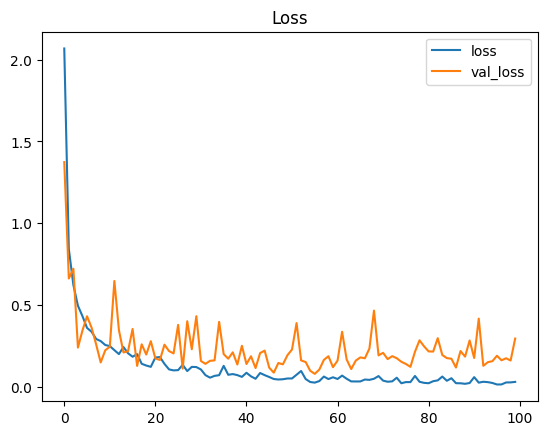

In [15]:
loss = hist.history["loss"]
val_loss = hist.history["val_loss"]

plt.plot(loss, label="loss")
plt.plot(val_loss, label="val_loss")
plt.title("Loss")
plt.legend()
plt.show()

Podemos ver lo mismo aquí, el accuracy es muy alto en ambos conjunto y estan muy a la par, lo que es señal de un modelo bien hecho.

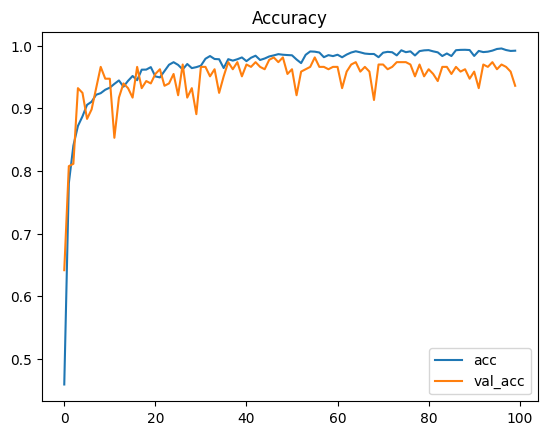

In [16]:
acc = hist.history["sparse_categorical_accuracy"]
val_acc = hist.history["val_sparse_categorical_accuracy"]

plt.plot(acc, label="acc")
plt.plot(val_acc, label="val_acc")
plt.title("Accuracy")
plt.legend()
plt.show()

In [17]:

train_loss, train_acc = model.evaluate(X_train, y_train_num, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val_num, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_num, verbose=0)

print("TRAIN:")
print("Loss:", round(train_loss,3))
print("Accuracy:", round(train_acc,3))

print("\nVALIDATION:")
print("Loss:", round(val_loss,3))
print("Accuracy:", round(val_acc,3))

print("\nTEST:")
print("Loss:", round(test_loss,3))
print("Accuracy:", round(test_acc,3))

TRAIN:
Loss: 0.04
Accuracy: 0.988

VALIDATION:
Loss: 0.294
Accuracy: 0.936

TEST:
Loss: 0.404
Accuracy: 0.925


# Matriz de confución

La matriz de confución muestra que el modelo tiene un rendimiento casí perfecto.

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 612ms/step


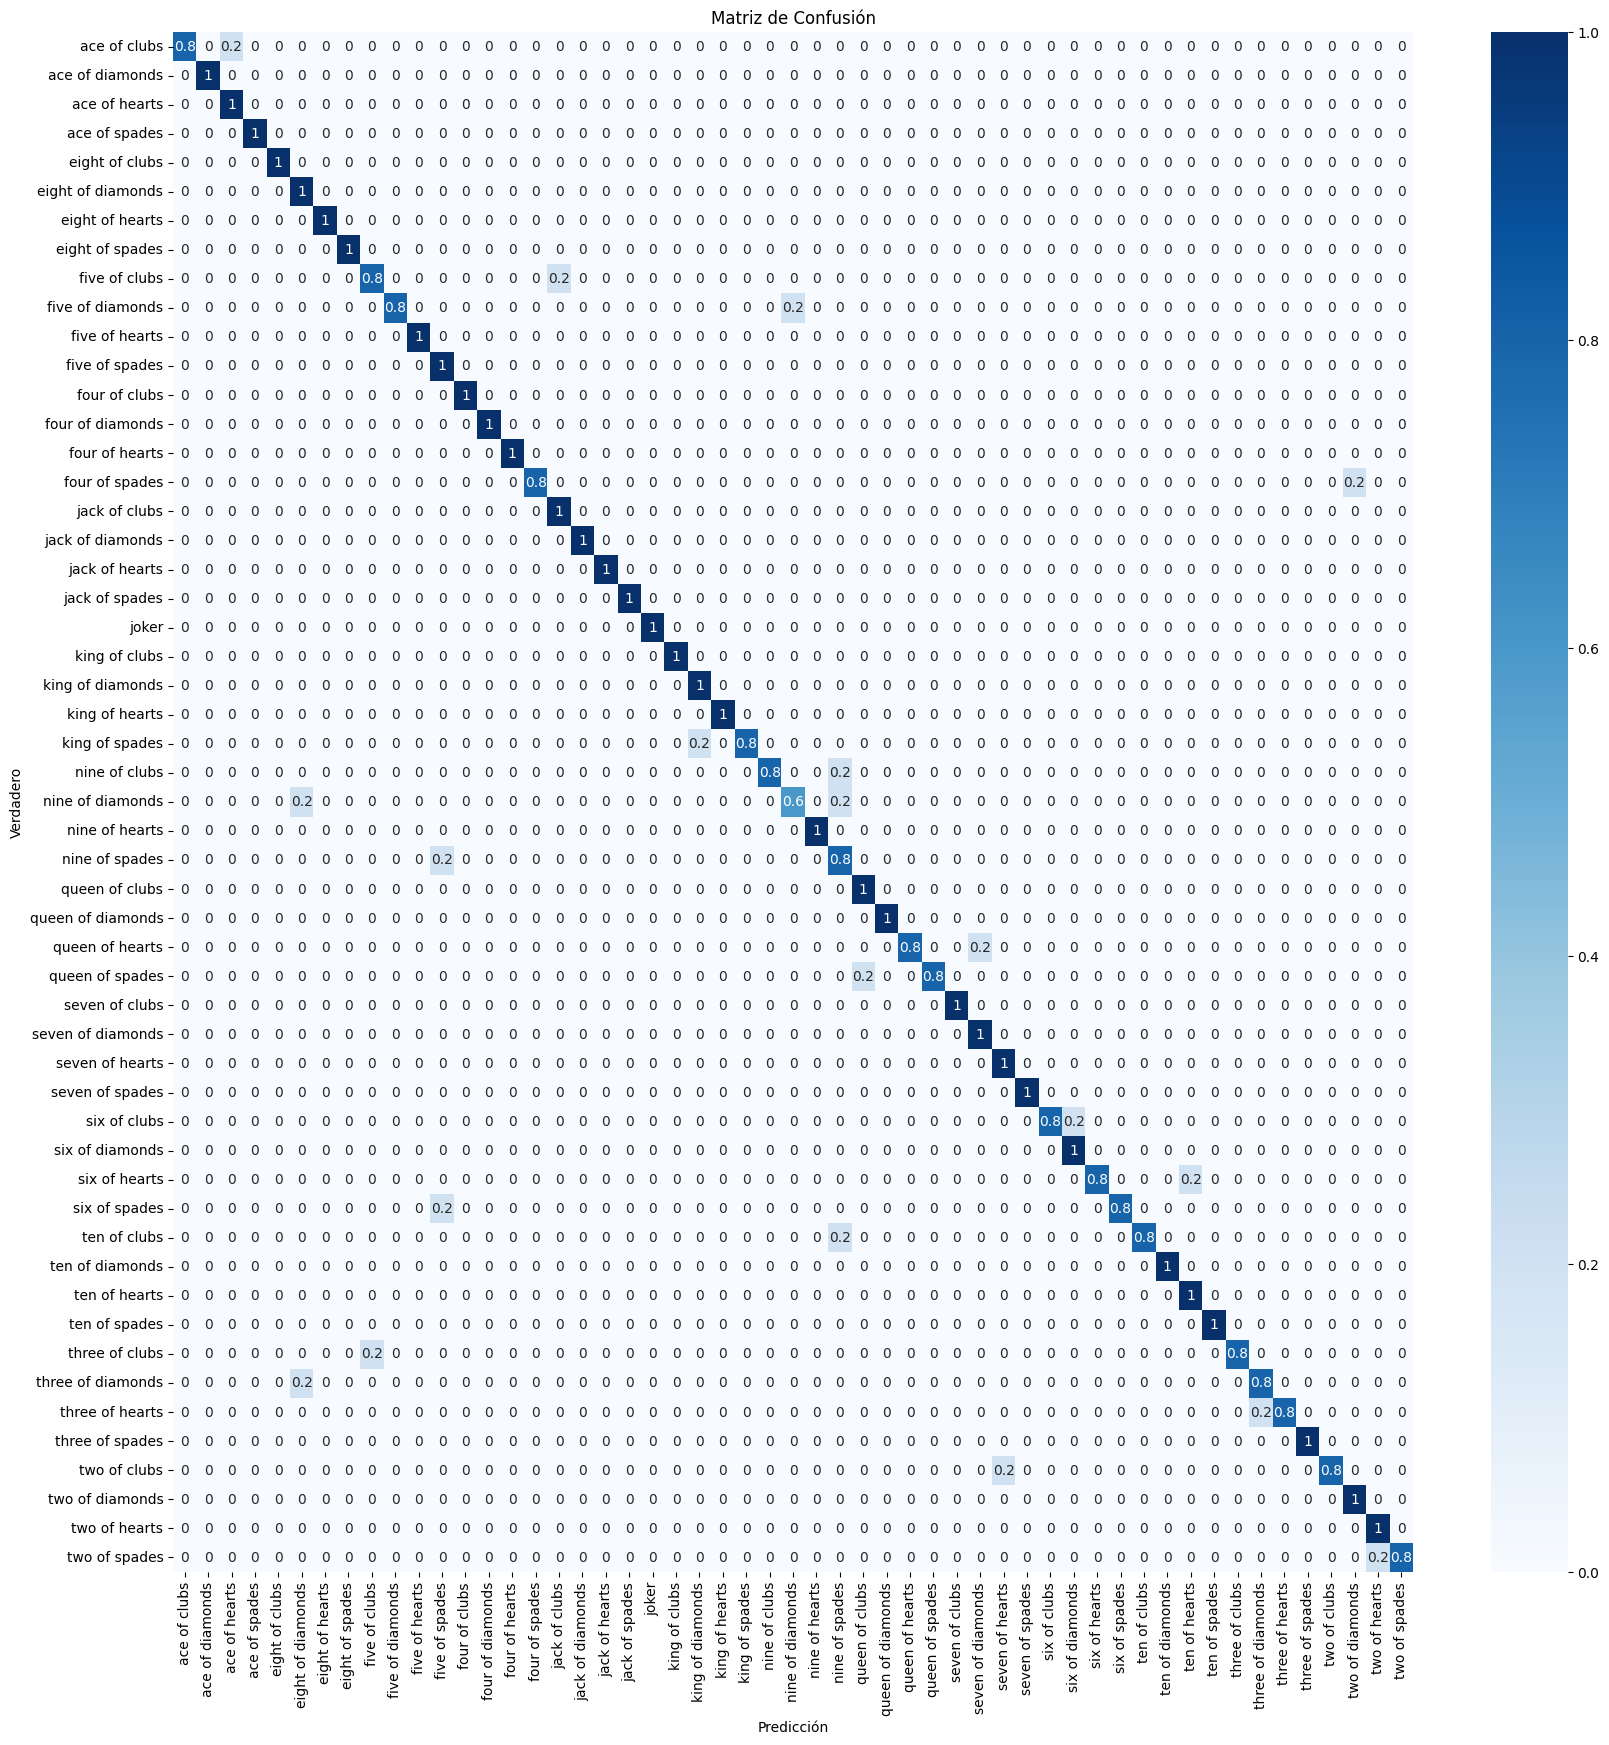

In [18]:
class_names = encoder.classes_

cm = confusion_matrix(y_test_num, np.argmax(model.predict(X_test), axis=1), normalize="true")

plt.figure(figsize=(20, 20))
sns.heatmap(cm,
            annot=True, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=True)

plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión')
plt.yticks(rotation=0)
plt.show()

# Conclusión

Este modelo parece ser nuestra mejor opción para resolver el problema, ya que, es el que goza de mejores metricas.